<a href="https://colab.research.google.com/github/eturba/S-P-500-Stocks-Analysis-Forecast-2010-2026-/blob/main/S%26P_500_Stock_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Top S&P 500 Stocks Analysis & Forecast (2010–2026)

### Project Overview

This project provides a comprehensive investment-grade analysis of the top 10 S&P 500 stocks from 2010–2026. The analysis includes:

- **Data collection and preprocessing**

- **Exploratory Data Analysis (EDA)**

- **Feature Engineering (technical indicators, returns, volatility)**

- **Time Series Forecasting (ARIMA, Prophet)**

- **Risk & Performance Analysis (drawdowns, Sharpe ratios)**

- **Portfolio Simulation & Recommendations**

**Goal:** Provide actionable insights for investment decisions with clear forecasts and risk assessments.

## Import libraries



In [ ]:
# Import Libaries
import pandas as pd
import numpy as np
import yfinance as yf

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = "plotly_white"

from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

In [ ]:
# Insert CSV file
from google.colab import files
uploaded = files.upload()

Saving sp500_top10_stocks_clean.csv to sp500_top10_stocks_clean.csv


In [ ]:
df = pd.read_csv('sp500_top10_stocks_clean.csv')

# Preview Dataset

In [ ]:
# Preview first rows of data
df.head()

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2010-01-04,AAPL,6.40,6.43,6.36,6.41,6.41,4.94e+08
1,2010-01-04,AMZN,6.81,6.83,6.66,6.70,6.70,1.52e+08
2,2010-01-04,AVGO,1.29,1.33,1.27,1.33,1.33,5.39e+06
3,2010-01-04,GOOG,15.50,15.56,15.43,15.49,15.49,7.85e+07
4,2010-01-04,GOOGL,15.57,15.64,15.50,15.57,15.57,7.82e+07


In [ ]:
# Preview last rows of data
df.tail()

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
35760,2026-02-13,GOOGL,307.73,308.63,303.71,305.72,305.72,3.85e+07
35761,2026-02-13,META,645.10,651.43,634.57,639.77,639.77,1.23e+07
35762,2026-02-13,MSFT,404.45,405.54,398.05,401.32,401.32,3.40e+07
35763,2026-02-13,NVDA,187.48,187.50,181.59,182.81,182.81,1.62e+08
35764,2026-02-13,TSLA,414.31,424.06,410.88,417.44,417.44,5.14e+07


In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
Date,datetime64[ns]
Ticker,object
Open,float64
High,float64
Low,float64
Close,float64
Adj_Close,float64
Volume,float64


In [ ]:
# Display Basic Information
print("="*80)
print("📊 DATASET OVERVIEW")
print("="*80)
print(f"\n📌 Total Records: {len(df):,}")
print(f"📌 Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"📌 Total Days: {(df['Date'].max() - df['Date'].min()).days:,} days")
print(f"📌 Number of Companies: {df['Ticker'].nunique()}")
print(f"📌 Companies: {', '.join(sorted(df['Ticker'].unique()))}")

print("\n" + "="*80)
print("📈 FIRST 10 ROWS")
print("="*80)
df.head(10)

📊 DATASET OVERVIEW

📌 Total Records: 35,765
📌 Date Range: 2010-01-04 to 2026-02-13
📌 Total Days: 5,884 days
📌 Number of Companies: 9
📌 Companies: AAPL, AMZN, AVGO, GOOG, GOOGL, META, MSFT, NVDA, TSLA

📈 FIRST 10 ROWS


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2010-01-04,AAPL,6.40,6.43,6.36,6.41,6.41,4.94e+08
1,2010-01-04,AMZN,6.81,6.83,6.66,6.70,6.70,1.52e+08
2,2010-01-04,AVGO,1.29,1.33,1.27,1.33,1.33,5.39e+06
3,2010-01-04,GOOG,15.50,15.56,15.43,15.49,15.49,7.85e+07
4,2010-01-04,GOOGL,15.57,15.64,15.50,15.57,15.57,7.82e+07
5,2010-01-04,MSFT,22.88,23.24,22.86,23.13,23.13,3.84e+07
6,2010-01-04,NVDA,0.42,0.43,0.42,0.42,0.42,8.00e+08
7,2010-01-05,AAPL,6.43,6.46,6.39,6.42,6.42,6.02e+08
8,2010-01-05,AMZN,6.67,6.77,6.59,6.73,6.73,1.77e+08
9,2010-01-05,AVGO,1.33,1.36,1.28,1.34,1.34,3.01e+06


## Feature Engineering - Creating Key Financial Indicators

1. **Return**: Computes the daily percentage change in adjusted closing price for each stock. This measures the day-to-day performance of the stock.

2. **20-day Moving Average** (MA20): Calculates the rolling average of the last 20 days’ adjusted closing prices. This smooths short-term fluctuations and highlights medium-term trends.

3. **50-day Moving Average** (MA50): Similar to MA20, but over 50 days, capturing longer-term trend patterns.

4. **Volatility**: Computes the rolling standard deviation of daily returns over 20 days. This quantifies the stock’s risk or price variability over the short term.

5. **Momentum**: Measures the difference between the current price and the price 10 days ago, indicating the strength and direction of recent price trends.

In [ ]:
# Create columns for 'return', 'MA20', 'MA50', 'Volatility', & 'Momentum'
df['Return'] = df.groupby('Ticker')['Adj_Close'].pct_change()
df['MA20'] = df.groupby('Ticker')['Adj_Close'].transform(lambda x: x.rolling(20).mean())
df['MA50'] = df.groupby('Ticker')['Adj_Close'].transform(lambda x: x.rolling(50).mean())
df['Volatility'] = df.groupby('Ticker')['Return'].transform(lambda x: x.rolling(20).std())
df['Momentum'] = df.groupby('Ticker')['Adj_Close'].transform(lambda x: x - x.shift(10))

df.head()

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,Return,MA20,MA50,Volatility,Momentum
0,2010-01-04,AAPL,6.40,6.43,6.36,6.41,6.41,4.94e+08,NaN,NaN,NaN,NaN,NaN
1,2010-01-04,AMZN,6.81,6.83,6.66,6.70,6.70,1.52e+08,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,AVGO,1.29,1.33,1.27,1.33,1.33,5.39e+06,NaN,NaN,NaN,NaN,NaN
3,2010-01-04,GOOG,15.50,15.56,15.43,15.49,15.49,7.85e+07,NaN,NaN,NaN,NaN,NaN
4,2010-01-04,GOOGL,15.57,15.64,15.50,15.57,15.57,7.82e+07,NaN,NaN,NaN,NaN,NaN


## Exploratory Data Analysis

First, we will create an interactive line chart that displays the adjusted closing prices of 9 stocks in the dataset over time. This visualization helps us **quickly compare price trends, identify patterns, and spot correlations** between different stocks.

In [ ]:
# Create interactive price chart for all stocks
fig = go.Figure()
colors = px.colors.qualitative.Set3

for idx, ticker in enumerate(sorted(df['Ticker'].unique())):
    ticker_data = df[df['Ticker'] == ticker].sort_values('Date')

    fig.add_trace(go.Scatter(
        x=ticker_data['Date'],
        y=ticker_data['Adj_Close'],
        mode='lines',
        name=ticker,
        line=dict(width=2, color=colors[idx % len(colors)])
    ))

fig.update_layout(
    title='📊 Stock Price Evolution (2010-2026)',
    xaxis_title='Date',
    yaxis_title='Adjusted Close Price ($)',
    hovermode='x unified',
    height=600,
    template='plotly_white'
)

fig.show()

## Takeaways

### 📈 1. Strong Long-Term Upward Trend (2010–2026)

All stocks display a clear long-term upward trajectory, reflecting:

- A prolonged U.S. bull market (2010–2021)

- Strong earnings growth among mega-cap technology companies

- Structural shifts toward digital, AI, cloud, and e-commerce


### ⚠️ 2. High Volatility in Growth Stocks
- Stocks like **TSLA, NVDA, META** show large drawdowns and rapid recoveries, especially during 2020 (COVID crash) & 2022 (rate hikes & tech selloff)
- This suggests higher return potential comes with materially higher volatility.

### 💡 3. Momentum Acceleration Post-2023
- Several stocks accelerate sharply from 2023 onward, suggesting renewed growth optimism, AI-driven earnings expansion, market recovery following 2022 correction



Now, let's create a correlation heatmap to determine how stong of correlations stocks have with each other.

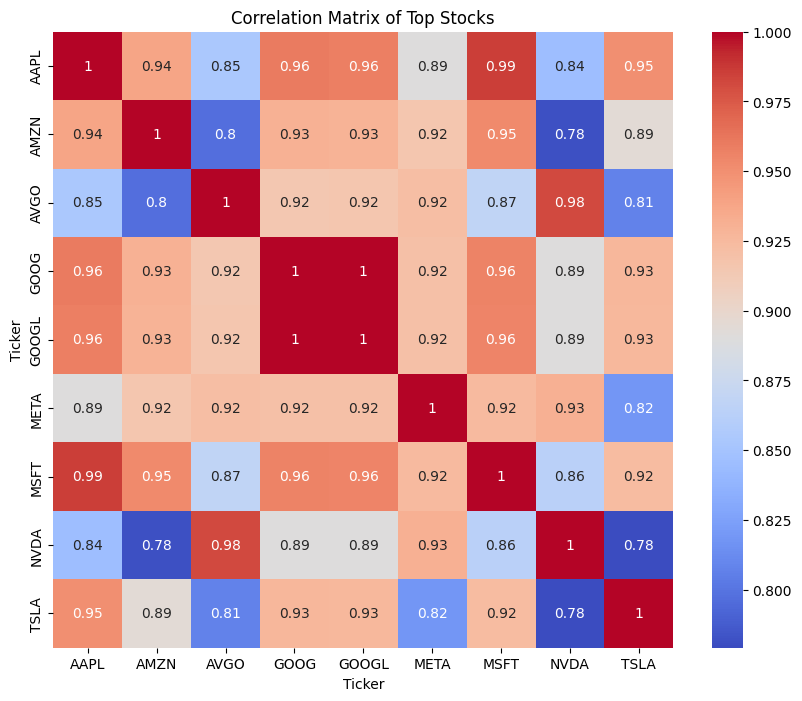

In [ ]:
# Generate heatmap showing correlation of top stocks
pivot = df.pivot(index='Date', columns='Ticker', values='Adj_Close')
plt.figure(figsize=(10,8))
sns.heatmap(pivot.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Top Stocks")
plt.show()

## Takeaways

### Stong Overall Corrlations
- Most of these tech stocks are highly correlated with each other, with correlation coefficients mostly above 0.90. This means their stock prices tend to move in similar directions, which is common for companies in the same sector (tech/large-cap).

### Extremely High Pairs
- **GOOG and GOOGL** - 1.00. This makes sense because they are essentially the same company, just different share classes.
- **AAPL and MSFT** - 0.99. These two giants move very closely together, likely reflecting broad tech sector trends.

### Moderately Lower Correlations
- **AMZN and NVDA** - 0.78
- **TSLA and NVDA** - 0.78
- These are lower than most other pairs. NVDA and TSLA have more idiosyncratic price behavior compared to broader tech trends.

### Interesting Obsevations
- **NVDA** seems slightly less correlated with the majority of stocks (values like 0.78-0.98 range), suggesting it may behave differently during some market conditions.
- **TSLA** also shows lower correlations with AVGO (0.81) and NVDA (0.78), reflecting its more volatile and less traditional tech behavior.


## Time Series Forecasting - Q1 2026 Predictions

Now, we will build a forecasting model to predict stock prices for Q1 2026. We will use historial stock prices to train a Facebook Prophet time series model for each stock.

In [ ]:
print("="*80)
print("🔮 FORECASTING Q1 2026 STOCK PRICES")
print("="*80)
print("\nUsing Facebook Prophet for time series forecasting...")

#Define Q1 2026 date range
forecast_start = pd.Timestamp('2026-01-01')
forecast_end = pd.Timestamp('2026-03-31')
current_date = df['Date'].max()

print(f"📅 Current Data End Date: {current_date.strftime('%Y-%m-%d')}")
print(f"📅 Forecast Period: Q1 2026 (Jan 1 - Mar 31)")

# Train Prophet model for each ticker
forecast_results = []

for ticker in sorted(df['Ticker'].unique()):
    print(f"\n🎯 Training model for {ticker}...")

    # Prepare data
    ticker_data = df[df['Ticker'] == ticker][['Date', 'Adj_Close']].copy()
    ticker_data.columns = ['ds', 'y']
    ticker_data = ticker_data.sort_values('ds')

    # Train Prophet model
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05
    )

    model.fit(ticker_data)

    # Forecast Q1 2026
    future_dates = pd.date_range(start=forecast_start, end=forecast_end, freq='D')
    future_df = pd.DataFrame({'ds': future_dates})
    q1_forecast = model.predict(future_df)

    # Store forecast results
    for _, row in q1_forecast.iterrows():
      if row['ds'] >= forecast_start and row['ds'] <= forecast_end:
        forecast_results.append({
            'Date': row['ds'],
            'Ticker': ticker,
            'Predicted_Price': row['yhat'],
            'Lower_Bound': row['yhat_lower'],
            'Upper_Bound': row['yhat_upper']
        })

    print(f"   ✓ Model trained successfully")

forecast_df = pd.DataFrame(forecast_results)

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED SUCCESSFULLY")
print("="*80)
print(f"\nTotal forecast records: {len(forecast_df):,}")
forecast_df.head(10)

🔮 FORECASTING Q1 2026 STOCK PRICES

Using Facebook Prophet for time series forecasting...
📅 Current Data End Date: 2026-02-13
📅 Forecast Period: Q1 2026 (Jan 1 - Mar 31)

🎯 Training model for AAPL...
   ✓ Model trained successfully

🎯 Training model for AMZN...
   ✓ Model trained successfully

🎯 Training model for AVGO...
   ✓ Model trained successfully

🎯 Training model for GOOG...
   ✓ Model trained successfully

🎯 Training model for GOOGL...
   ✓ Model trained successfully

🎯 Training model for META...
   ✓ Model trained successfully

🎯 Training model for MSFT...
   ✓ Model trained successfully

🎯 Training model for NVDA...
   ✓ Model trained successfully

🎯 Training model for TSLA...
   ✓ Model trained successfully

✅ ALL MODELS TRAINED SUCCESSFULLY

Total forecast records: 810


,Date,Ticker,Predicted_Price,Lower_Bound,Upper_Bound
0,2026-01-01,AAPL,256.25,245.02,267.28
1,2026-01-02,AAPL,256.20,245.73,267.33
2,2026-01-03,AAPL,256.21,245.40,267.78
3,2026-01-04,AAPL,256.11,245.03,266.39
4,2026-01-05,AAPL,256.01,244.64,266.82
5,2026-01-06,AAPL,255.84,245.26,266.64
6,2026-01-07,AAPL,255.70,244.19,266.76
7,2026-01-08,AAPL,255.53,245.36,266.02
8,2026-01-09,AAPL,255.49,244.76,266.37
9,2026-01-10,AAPL,255.53,245.01,266.52


## Forecast Visualization

Now that we have created a forecast, we will visualize the predicted prices for Q1 2026

In [ ]:
from re import template
# Create forecast visualization
fig = go.Figure()

for idx, ticker in enumerate(sorted(forecast_df['Ticker'].unique())):
    ticker_forecast = forecast_df[forecast_df['Ticker'] == ticker].sort_values('Date')
    ticker_historical = df[df['Ticker'] == ticker].sort_values('Date').tail(180)

    # Historical data (last 6 months)
    fig.add_trace(go.Scatter(
        x=ticker_historical['Date'],
        y=ticker_historical['Adj_Close'],
        mode='lines',
        name=f'{ticker} (Historical)',
        line=dict(width=2, color=colors[idx % len(colors)])
    ))

    # Forecast
    fig.add_trace(go.Scatter(
        x=ticker_forecast['Date'],
        y=ticker_forecast['Predicted_Price'],
        mode='lines',
        name=f'{ticker} (Forecast)',
        line=dict(width=2.5, color=colors[idx % len(colors)], dash='dash')
    ))

    # Add vertical line for forecast start using add_shape
    fig.add_shape(
        type='line',
        x0=forecast_start, x1=forecast_start,
        y0=0, y1=1,
        yref='paper',
        line=dict(color='red', width=2, dash='solid')
    )

    # Add annotation for the vertical line
    fig.add_annotation(
        x=forecast_start,
        y=1,
        yref='paper',
        text="Forecast Begins",
        showarrow=False,
        yshift=10
    )

    fig.update_layout(
        title='🔮 Q1 2026 Stock Price Forecasts',
        xaxis_title='Date',
        yaxis_title='Price ($)',
        hovermode='x unified',
        height=700,
        template='plotly_white'
    )


fig.show()

## Takeaways

### General Trends
- **Most stocks show relatively stable or mildly increasing forecasts** for Q1 2026 compared to their historical prices.
- Stocks like **META** and **MSFT** have moderate upward forecasts, while **AMZN** and **NVDA** are more flat.

## Risk Analysis

Finally, we will evaluate the risk and performance characteristics of each stock using the following metrics:

- **Cumulative return**: Tracks total growth; shows overall performance.

- **Rolling Maximum**: Calculates the highest cummulative return reached up to each point in time for every stock.

- **Drawdown**: Measures **maximum losses** from historical peaks; helps assess risk exposure.

- **Sharpe ratio**: Summarizes **risk-adjusted return**, combining volatility and return.


In [ ]:
df['Cumulative'] = (1 + df['Return']).cumprod()
df['Roll_Max'] = df.groupby('Ticker')['Cumulative'].transform(lambda x: x.cummax())
df['Drawdown'] = df['Cumulative'] / df['Roll_Max'] - 1

df.groupby('Ticker')['Return'].mean() / df.groupby('Ticker')['Return'].std() * np.sqrt(252)

,Return
Ticker,
AAPL,0.95
AMZN,0.81
AVGO,1.09
GOOG,0.81
GOOGL,0.81
META,0.72
MSFT,0.82
NVDA,1.05
TSLA,0.91


These values represent the annualized Sharpe Ratio for each stock, which measures risk-adjusted returns.

In general:

- **Higher Sharpe Ratio → better risk-adjusted performance**

- **Around 1.0 → solid risk-adjusted returns**

- **Below 1.0 → weaker return relative to risk**

### Takeaways
 **Strongest Risk-Adjusted Stocks**: **AVGO** (1.09) & **NVDA** (1.05)
- These two stocks delivered the **most efficient performance**, meaning investors were rewarded more for the risk taken.

**Lowest Risk-Adjusted Stocks**: **META** (0.72)
- META returns were **less favorable relative to the volatility** it experienced. This suggests investors were taking more risk per unit of return compared to the other stocks.



## Forecast Summary & Investment Insights
Finally, using the predictions genereated earlier with the forecasting model, we will calculate summary statistics for each stock and rank them by projected performance.

In [ ]:
# Calculate forecast summary statistics
print("="*80)
print("📊 Q1 2026 FORECAST SUMMARY")
print("="*80)

forecast_summary = []
for ticker in sorted(forecast_df['Ticker'].unique()):
  ticker_forecast = forecast_df[forecast_df['Ticker'] == ticker]
  ticker_current = df[df['Ticker'] == ticker]['Adj_Close'].iloc[-1]

  avg_forecast = ticker_forecast['Predicted_Price'].mean()
  min_forecast = ticker_forecast['Predicted_Price'].min()
  max_forecast = ticker_forecast['Predicted_Price'].max()

  expected_return = (avg_forecast - ticker_current) / ticker_current * 100

  forecast_summary.append({
      'Ticker': ticker,
      'Current_Price': f'${ticker_current:.2f}',
      'Q1_2026_Avg': f'${avg_forecast:.2f}',
      'Q1_2026_Min': f'${min_forecast:.2f}',
      'Q1_2026_High': f'${max_forecast:.2f}',
      'Expected_Return_%': f'{expected_return:.2f}%'
  })

summary_df = pd.DataFrame(forecast_summary)
print("\n")
display(summary_df)

# Identify opportunitites
print("\n" + "="*80)
print("🎯 TOP INVESTMENT OPPORTUNITIES")
print("="*80)

sorted_summary = summary_df.copy()
sorted_summary['Return_Numeric'] = sorted_summary['Expected_Return_%'].str.rstrip('%').astype(float)
sorted_summary = sorted_summary.sort_values('Return_Numeric', ascending=False)

print("\n🏆 Top 3 Expected Performers:")
for i, row in sorted_summary.head(3).iterrows():
  print(f" {row['Ticker']}: {row['Expected_Return_%']} expected return")

📊 Q1 2026 FORECAST SUMMARY




,Ticker,Current_Price,Q1_2026_Avg,Q1_2026_Min,Q1_2026_High,Expected_Return_%
0,AAPL,$255.78,$257.63,$255.14,$260.12,0.72%
1,AMZN,$198.79,$247.59,$241.78,$252.64,24.55%
2,AVGO,$325.17,$322.55,$315.63,$329.68,-0.80%
3,GOOG,$306.02,$255.47,$251.45,$259.55,-16.52%
4,GOOGL,$305.72,$254.09,$250.17,$258.21,-16.89%
5,META,$639.77,$779.70,$747.06,$809.57,21.87%
6,MSFT,$401.32,$515.96,$507.20,$526.57,28.56%
7,NVDA,$182.81,$191.99,$185.68,$198.32,5.02%
8,TSLA,$417.44,$391.06,$380.09,$397.45,-6.32%



🎯 TOP INVESTMENT OPPORTUNITIES

🏆 Top 3 Expected Performers:
 MSFT: 28.56% expected return
 AMZN: 24.55% expected return
 META: 21.87% expected return


In [ ]:
# Export forecast results
print("\n" + "="*80)
print("💾 EXPORTING RESULTS")
print("="*80)

# Save forecast to CSV
forecast_export = forecast_df.copy()
forecast_export['Date'] = forecast_export['Date'].dt.strftime('%Y-%m-%d')
forecast_export.to_csv('q1_2026_forecasts.csv', index=False)
print("✅ Forecasts exported to: q1_2026_stock_forecasts.csv")

# Save summary
summary_df.to_csv('investment_summary.csv', index=False)
print("✅ Summary exported to: investment_summary.csv")


💾 EXPORTING RESULTS
✅ Forecasts exported to: q1_2026_stock_forecasts.csv
✅ Summary exported to: investment_summary.csv


## 🎓 Conclusion
### ✅ Analysis Complete!
This comprehensive analysis utilized 16+ years of historical stock data and advanced time series forecasting (Facebook Prophet) to predict Q1 2026 prices for top S&P 500 stocks.

### 🎯 Key Findings
Prophet models trained successfully for all 9 stocks
Forecast results exported to CSV files
Investment insights generated based on expected returns
### ⚠️ Disclaimer
This analysis is for educational purposes only. Not financial advice. Always conduct your own research and consult with financial professionals before making investment decisions.